# Project 2

## Utils

In [1]:
import numpy as np
from math import sqrt, log
from scipy import stats
from joblib import Parallel, delayed
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def f_lambda(a,b,t):
    return a*t**2 + b*t

def insert_into_sorted_list(sorted_list, new_tuple):
    """Inserts a tuple (e, t) into a list sorted in descending order
    based on the second element (t).
    """
    #print(new_tuple)
    new_t = new_tuple[2]
    
    # Iterate through the list to find the correct position
    for i, (_, _,current_t) in enumerate(sorted_list):
        if new_t >= current_t:
            sorted_list.insert(i, new_tuple)
            return sorted_list
            
    # If new_t is smaller than all existing elements,
    # append it to the end.
    sorted_list.append(new_tuple)
    return sorted_list

def first_index_le_zero(arr):
    """Returns the first index where the coordinate is <= 0.
    Returns None if no such coordinate exists.
    """
    # Find all indices where the condition is True
    indices = np.where(arr <= 0)[0]
    
    # If the resulting array is not empty, return the first index
    return indices[0] if indices.size > 0 else None

In [3]:
def sample_acceptance_exponential(f, lambda_max, t):
    Accepted = False
    x = np.random.exponential(scale = 1/lambda_max)
    acceptance_rate = f(x+t)/lambda_max
    u = np.random.uniform()
    if u < acceptance_rate :
        Accepted = True
    return Accepted, x

## Primary task : simulation

### Event based hospital class

In [132]:
class hostpital_EB :

    def __init__(self, a, b, LOS_Parameters, f_lambda, lambda_3, capacities, limit, LOS_distribution = 'LN'):
        self.t = 0 # current time

        self.a = a
        self.b = b

        self.lambda_3 = lambda_3
        self.f_lambda1 = lambda t : f_lambda(self.a,self.b,t)
        self.f_lambda2 = lambda t : f_lambda(self.a/5,self.b/5,t)
        self.lambda_max = self.f_lambda1(-self.b/(2*self.a))
        self.LOS = LOS_Parameters

        self.Capacities = np.array(capacities)
        self.limit = limit

        self.Wards = np.zeros(3) # nb of occupied bed per ward
        self.Ward_history = {i : [] for i in range(3)} # list of number of occupied beds per ward
        self.Flows = np.zeros((4,2)) # History of accepted/refused customers per ward
        self.PL = [] # Priority list

        self.LOS_distribution = LOS_distribution

    def sample_inter_arrival(self,w,t):
        if w == 0 :
            return sample_acceptance_exponential(self.f_lambda1, self.lambda_max, t)
        elif w ==1 : 
            return sample_acceptance_exponential(self.f_lambda2, self.lambda_max/5, t)
        elif w ==2 :
            return True, np.random.exponential(1/self.lambda_3)
        
    def reinitialize(self):
        self.PL = []
        self.t = 0
        self.Wards = np.zeros(3)
        self.Flows = np.zeros((3,2))
        self.Ward_history = {i : [] for i in range(3)}
    
    

######################## Schedule functions ###########################

    def schedule_free_bed(self,w):
        if self.LOS_distribution == "LN" :
            sojourn = np.random.lognormal(mean = self.LOS[w][0], sigma=self.LOS[w-1][1])
        elif self.LOS_distribution == "exp" :
            sojourn = np.random.exponential(scale = self.LOS[w])
        insert_into_sorted_list(self.PL,(("FB",w,self.t + sojourn)))

    def schedule_arrival(self,w,t,limit):
        is_accepted = False
        while (not is_accepted) and (t < limit) :
            is_accepted, x = self.sample_inter_arrival(w,t)
            t += x
        #print(f"Proposal x = {x} is accepted : {is_accepted} for ward w = {w}")
        if is_accepted :
            insert_into_sorted_list(self.PL,("Arr",w,t))

######################## Event functions ###########################

    def Free_bed(self,w):
        if self.Wards[w] > 0 :
            self.Wards[w] -= 1
            self.Ward_history[w].append((self.Wards[w],self.t)) # New bed available at time t in ward w

    def Arrive_ward(self,w,former_B = False):
        if self.Wards[w] < self.Capacities[w]: # If a bed is available in ward w
            self.Wards[w] += 1 # One more bed occupied
            if former_B :
                self.Flows[3][1] += 1 # special case of patient refused from ward B and accepted in A
            else :
                self.Flows[w][1] += 1 # A patient from ward w is accepted
            self.Ward_history[w].append((self.Wards[w],self.t)) # New occupied bed at time t in ward w
            #print(f"bed given at {self.t} in ward {w}")
            self.schedule_free_bed(w)
        elif w == 1 and self.Wards[0] < self.Capacities[0]: # If the patient arrives at a full Ward B but space in Ward A
            self.Arrive_ward(0,former_B=True) # New patient arrives at Ward A
        else : # If no bed is available 
            self.Flows[w][0] += 1 # Patient refused at Ward w
        

###################### Main algorithm : Step_function ###############

    def initialize(self):
        for w in range(3):
            self.schedule_arrival(w,self.t, self.limit)

    def Step_function(self, limit):
        
        if self.t == 0 :
            self.initialize()
            
        Event_type, w, new_t = self.PL.pop() # returns last tuple of PL list
        #print(Event_type, w)

        if new_t < limit :
            self.t = new_t  # update time 
            if Event_type == "Arr" : 
                self.Arrive_ward(w)
                #print(self.Ward_history)
                self.schedule_arrival(w, self.t, self.limit)
            else :
                self.Free_bed(w)

        else :
            self.t = limit

    

### Tests

In [142]:
LOS = [(log(4*sqrt(2)),sqrt(log(2))), (log(6*sqrt(2)), sqrt(log(2))), (log(5*sqrt(2)), sqrt(log(2)))]
lambda_3 = 6

nb_A =  30   #30
nb_B =  20   #20
nb_C = 75 - nb_A - nb_B
Capacities = [nb_A,nb_B,nb_C]

limit = 365

a = -1/3650
b = 1/10

In [143]:
H = hostpital_EB(
    a = a,
    b = b,
    LOS_Parameters=LOS,
    f_lambda=f_lambda,
    lambda_3=lambda_3,
    capacities= Capacities,
    limit= limit 
)

#IA = H.sample_inter_arrival(0)
#print(IA, H.t)
limit = 365
epsilon = 0.01
#H.reinitialize()
iteration = 0
while H.t < limit - epsilon :
    if iteration % 100 == 0 :
        print(f"\niteration {iteration}, time : {H.t}")
    H.Step_function(limit)
    iteration += 1


iteration 0, time : 0

iteration 100, time : 10.49320030422775

iteration 200, time : 19.614947777769814

iteration 300, time : 26.812641130352826

iteration 400, time : 32.72498450101932

iteration 500, time : 39.23237434992205

iteration 600, time : 44.658732511738144

iteration 700, time : 49.82072213305105

iteration 800, time : 55.940329132752275

iteration 900, time : 61.262539759635345

iteration 1000, time : 65.71465519457885

iteration 1100, time : 71.85553660808537

iteration 1200, time : 77.71449588284025

iteration 1300, time : 82.57095292464336

iteration 1400, time : 87.84874797664311

iteration 1500, time : 92.93555613571417

iteration 1600, time : 97.07592857288759

iteration 1700, time : 102.31922732060602

iteration 1800, time : 106.80349451794339

iteration 1900, time : 111.42142385149829

iteration 2000, time : 115.5524389575519

iteration 2100, time : 120.40320322388483

iteration 2200, time : 124.35973523799211

iteration 2300, time : 129.14100281398706

iteratio

## Primary performances measures

In [144]:
mu = (H.a*(365**3)/3 + H.b*(365**2)/2)
print("mean of lambda(t) : ",mu/365)

mean of lambda(t) :  6.083333333333334


In [145]:
names = ["A", "B", "C"]
for w in range(3):
    print(f"Ward {names[w]} : {int(np.sum(H.Flows[w][1] + (w == 1)*H.Flows[3][1]))} accepted people \n         {int(np.sum(H.Flows[w][0]))} rejected people")
    L = H.Ward_history[w]
    print(L)
    mean_nb_occupied = (np.sum([(L[i][1]-L[i-1][1])*L[i-1][0] for i in range(1,len(L))]))/365 + (365-L[-1][1])*L[-1][0]/365
    print(f"         {mean_nb_occupied:.4f} mean number of occupied bed")

Ward A : 1123 accepted people 
         1107 rejected people
[(np.float64(1.0), 2.397969430449241), (np.float64(2.0), 3.3620207283960686), (np.float64(1.0), 3.4296479958305905), (np.float64(2.0), 5.670174471646269), (np.float64(3.0), 7.766423627230208), (np.float64(4.0), 9.08711931230907), (np.float64(5.0), 10.939335965058973), (np.float64(4.0), 11.282942600117508), (np.float64(3.0), 11.628086060948025), (np.float64(4.0), 12.049588169445707), (np.float64(5.0), 12.742853991583356), (np.float64(4.0), 12.848268933685134), (np.float64(5.0), 13.442612153533473), (np.float64(4.0), 13.904388649268228), (np.float64(5.0), 14.804051771343548), (np.float64(6.0), 16.876991554385164), (np.float64(5.0), 16.92030210361078), (np.float64(4.0), 17.532503682748185), (np.float64(5.0), 18.033328689964073), (np.float64(6.0), 19.293081887258705), (np.float64(7.0), 19.29870142132237), (np.float64(8.0), 19.524706292350622), (np.float64(9.0), 20.304726339321665), (np.float64(8.0), 21.008631826174216), (np.float

In [73]:
# Probability that all beds are occupied for each of the three patient types
for w in range(3):
    print(f"Probability that all beds are occupied for a patient of type {w} : {H.Flows[w][0]/np.sum(H.Flows[w]):.4f}")

Probability that all beds are occupied for a patient of type 0 : 0.4645
Probability that all beds are occupied for a patient of type 1 : 0.0413
Probability that all beds are occupied for a patient of type 2 : 0.5878


In [78]:
def Relocated(nb_A,nb_B,nb_beds=75, limit = 365, LOS = LOS, f_lambda =  f_lambda, lambda_3 = lambda_3, mask = [1,1,1],a = -1/3650, b = 1/10, total = False):
    """Number of relocated people from wards chosen with the mask"""
    
    capacities = [nb_A,nb_B, nb_beds-nb_A-nb_B]
    H = hostpital_EB(
        a = a,
        b = b,
        LOS_Parameters=LOS,
        f_lambda=f_lambda,
        lambda_3=lambda_3,
        capacities= capacities,
        limit= limit 
        )
    while H.t < H.limit :
        H.Step_function(limit)
    if total :
        tot = 0
        for w in range(3):
            tot += mask[w]*np.sum(H.Flows[:3,:][w]) 
        tot += mask[1]*H.Flows[3][1]

        return np.sum([mask[w]*H.Flows[:3][w][0] for w in range(3)]), tot
    else :
        return np.sum([mask[w]*H.Flows[:3,:][w][0] for w in range(3)])

In [103]:
# Sanity check : Does the average obeserved number of patient per ward match the theory ?

Integral = (H.a*(365**3)/3 + H.b*(365**2)/2) # Integral of lambda(t)dt between 0 and 365
mu_total = np.array([Integral, 0.2*Integral, 6*365]) # Average number of people coming every year
var_total = mu_total.copy() # Variance of the total number of people coming every year
L = []
for i in range(100): 
    _,tot = Relocated(20,20,mask = [0,1,0], total = True)
    L.append(tot)
print(np.mean(L))
print(mu_total[1])

443.06
444.0833333333334


In [ ]:
def Control_variate(nb_A,nb_B,nb_beds,N, mask = [1,1,1], original = False):
    """Number of relocated patients from wards chosen with the mask.

    This control variate version uses the total number of patient every year
    as the control variable"""

    R = np.zeros(N)
    Tot = np.zeros(N)
    for i in range(N):
        r,tot = Relocated(nb_A,nb_B,nb_beds,mask = mask,total=True)
        R[i] = r
        Tot[i] = tot
    c = np.cov(R,Tot)[0][1]/np.sum(var_total*mask)
    if original : 
        #print(np.shape(R),np.shape(Tot),np.shape(mu_total*mask))
        return R - c*(Tot-np.sum(mu_total*mask)), R
    else :
        return R - c*(Tot-np.sum(mu_total*mask))

In [105]:
N = 100
masks = [[1,0,0], [0,1,0], [0,0,1], [1,1,1]]
strings = ["Ward A", "Ward B", "Ward C", "all wards"]


for w in range(4):

    Y,R = Control_variate(nb_A=nb_A,nb_B=nb_B, nb_beds=75, N= N, mask=masks[w],original=True)
    R_bar = np.mean(R)
    s1 = np.std(R,ddof = 1)

    alpha = 0.05
    t = stats.t.ppf(1-0.05, df = N-1)
    ic_inf1 = R_bar - t*s1/sqrt(N)
    ic_sup1 = R_bar + t*s1/sqrt(N)
        

    print(f"Estimated number of relocated patients from  {strings[w]} without control variate : {R_bar:.2f},   IC = [{ic_inf1:.2f},{ic_sup1:.2f}]")

    Y_bar = np.mean(Y)
    s2 = np.std(Y,ddof = 1)

    alpha = 0.05
    t = stats.t.ppf(1-0.05, df = N-1)
    ic_inf2 = Y_bar - t*s2/sqrt(N)
    ic_sup2= Y_bar + t*s2/sqrt(N)
    

    print(f"Estimated number of relocated patients from  {strings[w]} with control variate:     {Y_bar:.2f},   IC = [{ic_inf2:.2f},{ic_sup2:.2f}]")
    print(f"Variance reduction : {100*(s1**2-s2**2)/(s1**2)} %")
    print(f"Std reduction : {100*(s1-s2)/(s1)} %")
    print("\n")

(100,) (100,) (3,)
Estimated number of relocated patients from  Ward A without control variate : 1067.15,   IC = [1058.65,1075.65]
Estimated number of relocated patients from  Ward A with control variate:     1064.84,   IC = [1059.41,1070.27]
Variance reduction : 59.19316073756935 %
Std reduction : 36.119768893318295 %


(100,) (100,) (3,)
Estimated number of relocated patients from  Ward B without control variate : 32.03,   IC = [30.25,33.81]
Estimated number of relocated patients from  Ward B with control variate:     31.69,   IC = [30.23,33.16]
Variance reduction : 32.097608635311616 %
Std reduction : 17.597092669804187 %


(100,) (100,) (3,)
Estimated number of relocated patients from  Ward C without control variate : 1289.80,   IC = [1280.56,1299.04]
Estimated number of relocated patients from  Ward C with control variate:     1284.59,   IC = [1279.50,1289.68]
Variance reduction : 69.65719114941548 %
Std reduction : 44.91569293293732 %


(100,) (100,) (3,)
Estimated number of relo

In [ ]:
# Sanity check
print(H.Flows)

[[1001. 1154.]
 [  17.  395.]
 [1295.  908.]
 [   0.   21.]]


## Sensitivity analysis : bed configurations

### Find the best configuration with 75 beds

In [108]:
N = 10 # Number of iteration per point to explore

# Generate the search triangle: a + b < 75
points = [(a, b) for a in range(75) for b in range(75) if a + b < 75]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean(Control_variate(a,b,75,N)))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 2850
Computation completed in 69.19 seconds.
The minimum found is at (42, 0) with a value of 2017.3808


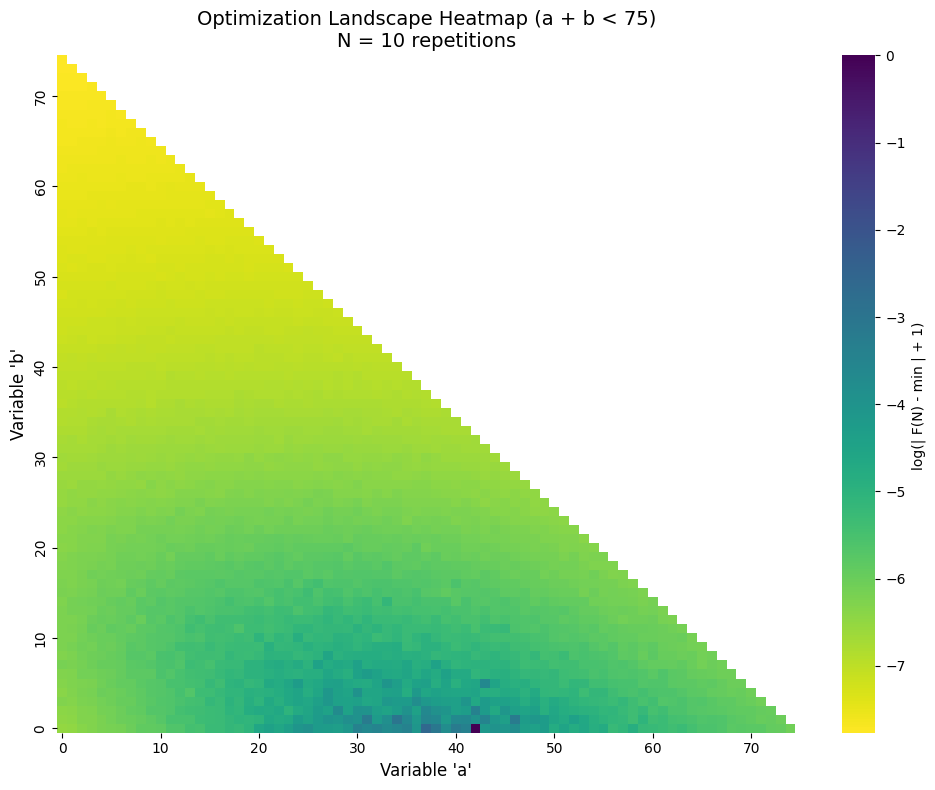

In [110]:
grid_size = 75
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 80 beds

In [113]:
N = 10 # Number of iteration per point to explore
nb_beds = 80

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean(Control_variate(a,b,nb_beds,N)))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 3240
Computation completed in 81.69 seconds.
The minimum found is at (39, 3) with a value of 1862.0372


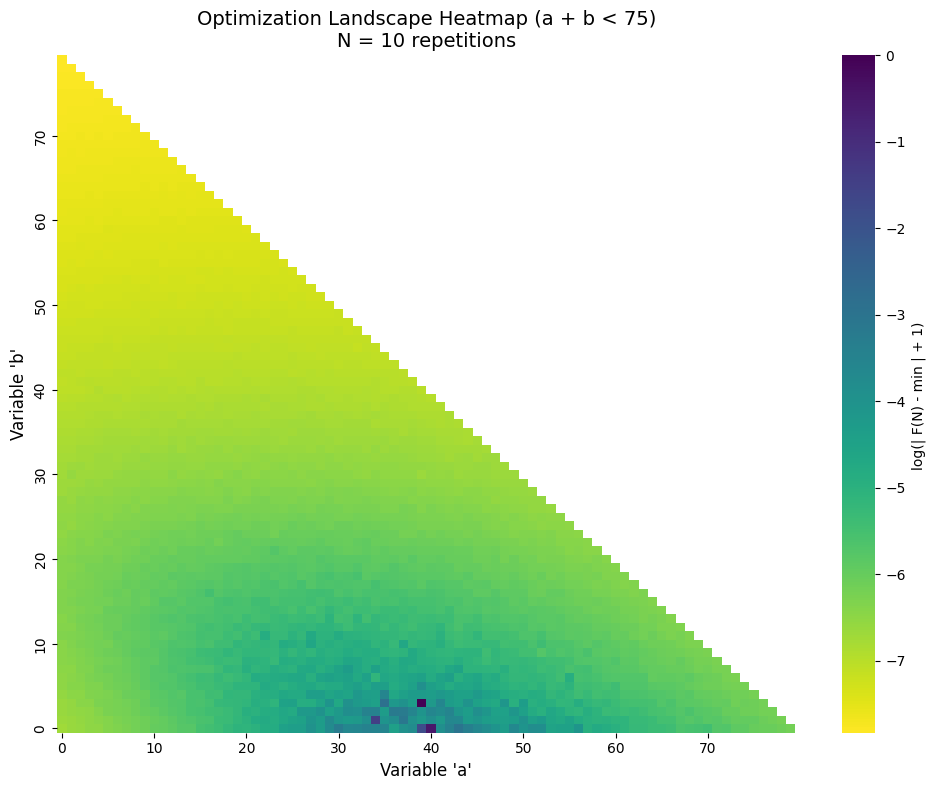

In [114]:
grid_size = 80
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 100 beds

In [115]:
N = 10 # Number of iteration per point to explore
nb_beds = 100

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean(Control_variate(a,b,nb_beds,N)))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 5050
Computation completed in 141.63 seconds.
The minimum found is at (54, 0) with a value of 1223.7856


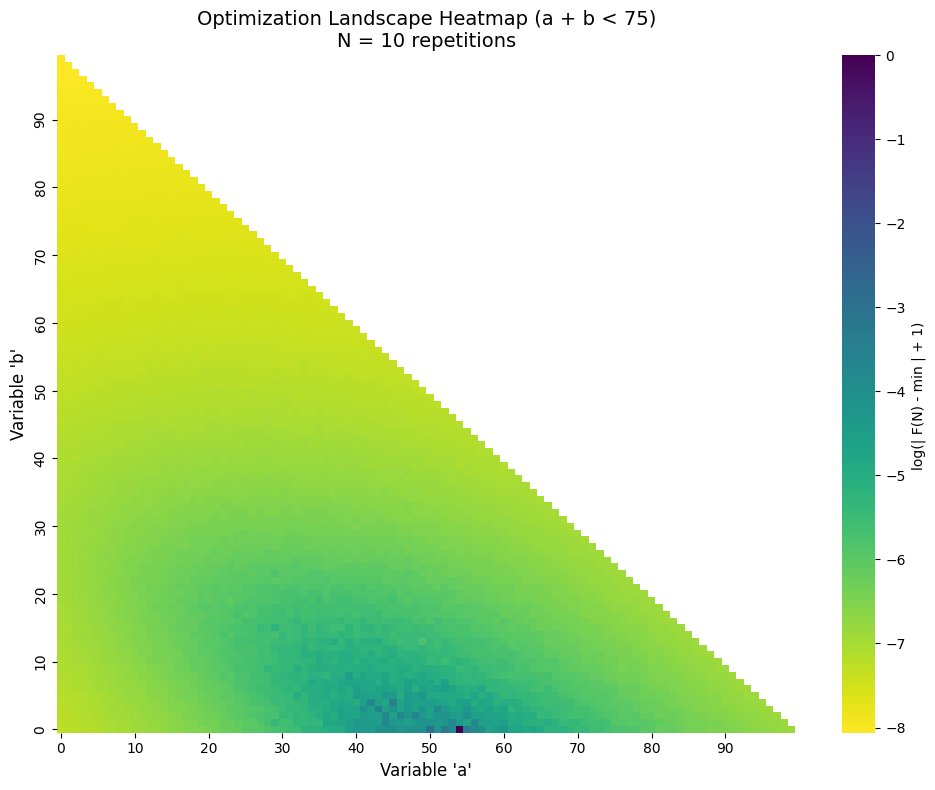

In [116]:
grid_size = 100
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 50 beds

In [117]:
N = 10 # Number of iteration per point to explore
nb_beds = 50

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean(Control_variate(a,b,nb_beds,N)))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 1275
Computation completed in 25.57 seconds.
The minimum found is at (31, 0) with a value of 2886.9442


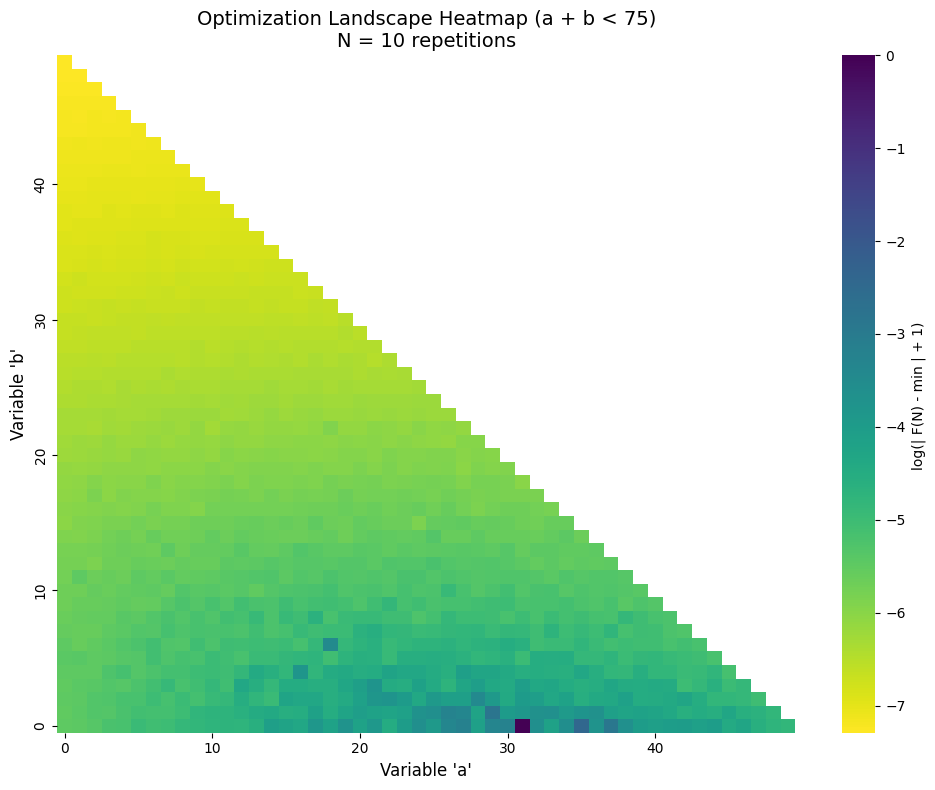

In [118]:
grid_size = 50
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 30 beds

In [119]:
N = 10 # Number of iteration per point to explore
nb_beds = 30

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean(Control_variate(a,b,nb_beds,N)))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 465
Computation completed in 7.76 seconds.
The minimum found is at (27, 0) with a value of 3623.8621


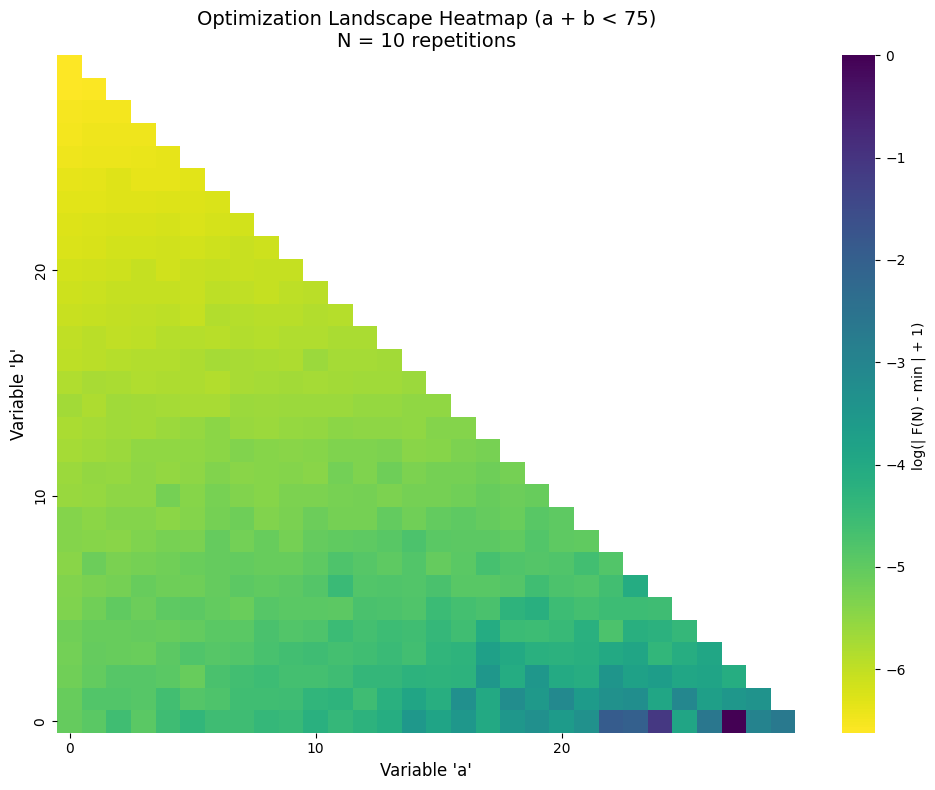

In [120]:
grid_size = 30
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

## Sensitivity analysis : different length of stay distributions

In [136]:
LOS = [log(4*sqrt(2)), log(6*sqrt(2)), log(5*sqrt(2))]
lambda_3 = 6

nb_A =  30   #30
nb_B =  20   #20
nb_C = 75 - nb_A - nb_B
Capacities = [nb_A,nb_B,nb_C]

limit = 365

a = -1/3650
b = 1/10

In [138]:
H = hostpital_EB(
    a = a,
    b = b,
    LOS_Parameters=LOS,
    f_lambda=f_lambda,
    lambda_3=lambda_3,
    capacities= Capacities,
    limit= limit,
    LOS_distribution="exp"
)

limit = 365
iteration = 0
while H.t < limit  :
    if iteration % 100 == 0 :
        print(f"\niteration {iteration}, time : {H.t}")
    H.Step_function(limit)
    iteration += 1


iteration 0, time : 0

iteration 100, time : 9.185338771764503

iteration 200, time : 15.266024883957595

iteration 300, time : 21.436639541691314

iteration 400, time : 26.403820279140408

iteration 500, time : 31.16896086732911

iteration 600, time : 36.20465638889339

iteration 700, time : 42.16473082999563

iteration 800, time : 47.61393934035405

iteration 900, time : 51.749957496334346

iteration 1000, time : 56.21519542773457

iteration 1100, time : 59.79564789946807

iteration 1200, time : 63.72727930309571

iteration 1300, time : 67.26232832649839

iteration 1400, time : 70.79460316395627

iteration 1500, time : 73.96367886887525

iteration 1600, time : 78.20643883091847

iteration 1700, time : 81.89456864297456

iteration 1800, time : 85.22853442709537

iteration 1900, time : 88.73245064599422

iteration 2000, time : 92.29121317205679

iteration 2100, time : 95.24888741752204

iteration 2200, time : 98.47523703723034

iteration 2300, time : 101.59842536600625

iteration 2400